# TD2 - Bank Churners

This notebook implements the TD2 preprocessing workflow on the BankChurners dataset.


# Notebook requirements

This notebook requires the dataset `BankChurners.csv` to be in the same folder. If you don't have it, download it from Kaggle and place it here.

Install required packages with:

```bash
pip install -r requirements.txt
```

In [1]:
# 1) Imports and settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import (RobustScaler, StandardScaler, MinMaxScaler,
                                   OrdinalEncoder, OneHotEncoder)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import joblib

%matplotlib inline
sns.set(style='whitegrid')

In [2]:
# 2) Load dataset and initial profile
from pathlib import Path
p = Path('BankChurners.csv')
if not p.exists():
    print('BankChurners.csv not found. Please download and place it in the notebook folder.')
else:
    raw = pd.read_csv(p)
    data = raw[raw.columns[:-2]].copy()
    print(f'Dimensions : {data.shape}')
    print('\nDtypes:\n', data.dtypes.value_counts())
    cat_cols = data.select_dtypes(include='object').columns
    for col in cat_cols:
        print(f'{col:35s} → {list(data[col].unique())[:10]}')
    display(data.describe().round(2))

Dimensions : (10127, 19)

Dtypes:
 int64      10
object      6
float64     3
Name: count, dtype: int64
Attrition_Flag                      → ['Existing Customer', 'Attrited Customer']
Gender                              → ['M', 'F']
Education_Level                     → ['High School', 'Graduate', 'Uneducated', 'Unknown', 'College', 'Post-Graduate', 'Doctorate']
Marital_Status                      → ['Married', 'Single', 'Unknown', 'Divorced']
Income_Category                     → ['$60K - $80K', 'Less than $40K', '$80K - $120K', '$40K - $60K', '$120K +', 'Unknown']
Card_Category                       → ['Blue', 'Gold', 'Silver', 'Platinum']


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct
count,1.012700e+04,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,7.391776e+08,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,7469.14,0.76,4404.09,64.86
std,3.690378e+07,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,9090.69,0.22,3397.13,23.47
min,7.080821e+08,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00
25%,7.130368e+08,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,1324.50,0.63,2155.50,45.00
50%,7.179264e+08,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3474.00,0.74,3899.00,67.00
75%,7.731435e+08,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,9859.00,0.86,4741.00,81.00
max,8.283431e+08,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,18484.00,139.00


Gender                    → 810 NaN (8%)
Education_Level           → 1215 NaN (12%)
Total_Trans_Amt           → 506 NaN (5%)


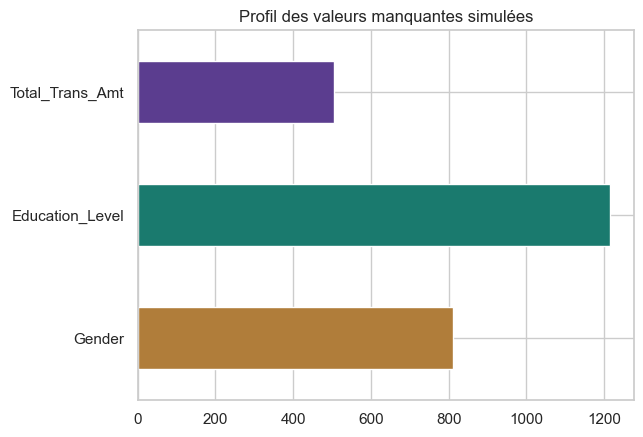

In [3]:
# 3) Simulate MCAR missing values
rng = np.random.default_rng(42)
datam = data.copy()
missing_config = {
    'Gender':          0.08,
    'Education_Level': 0.12,
    'Total_Trans_Amt': 0.05,
}

for col, rate in missing_config.items():
    n_missing = int(len(datam) * rate)
    idx = rng.choice(datam.index, size=n_missing, replace=False)
    datam.loc[idx, col] = np.nan
    print(f'{col:25s} → {n_missing} NaN ({rate*100:.0f}%)')

missing = datam.isnull().sum()[lambda s: s > 0]
if not missing.empty:
    missing.plot(kind='barh', color=['#B07D3A','#1A7A6E','#5B3D8F'])
    plt.title('Profil des valeurs manquantes simulées')
    plt.show()
else:
    print('No simulated missing values found.')

Warning - these columns are missing and will be skipped: ['Avg_Utilization_Ratio']


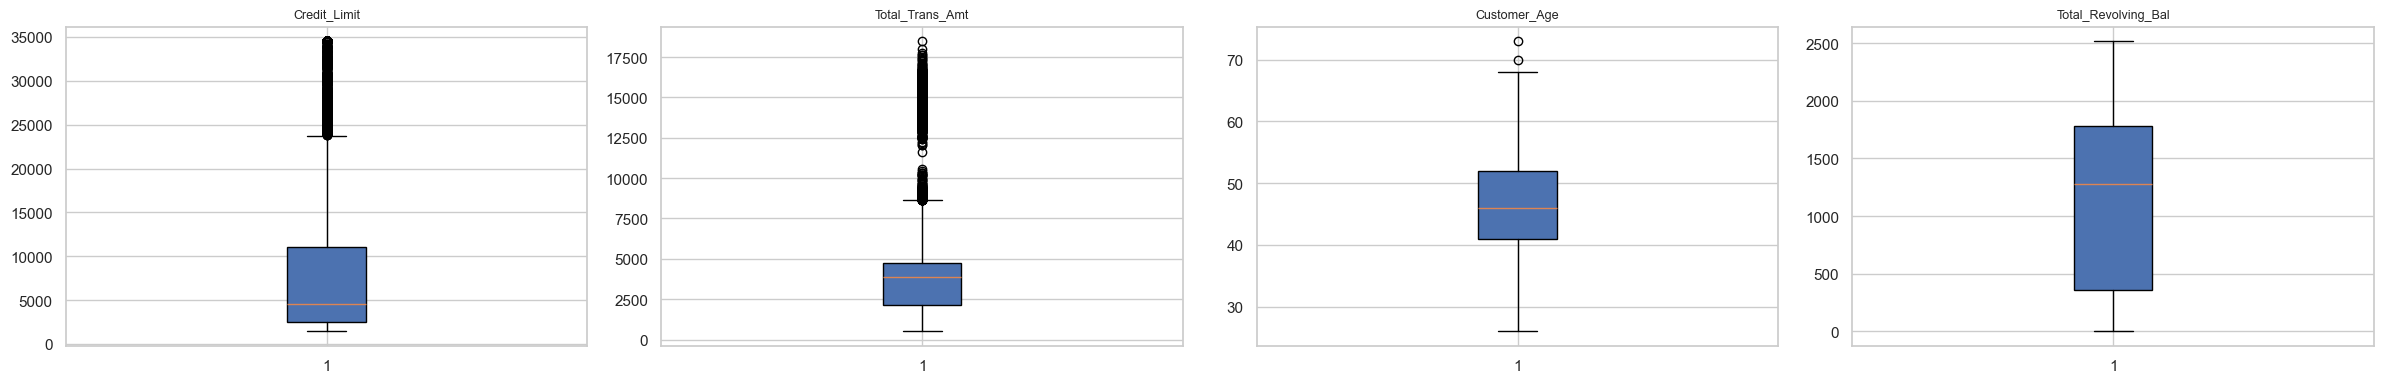

Variable                         N outliers        %
Credit_Limit                            984     9.7%
Total_Trans_Amt                         896     8.8%
Customer_Age                              2     0.0%
Total_Revolving_Bal                       0     0.0%


In [4]:
# 4) Outliers detection — IQR method
num_key = ['Credit_Limit','Total_Trans_Amt',
           'Customer_Age','Total_Revolving_Bal',
           'Avg_Utilization_Ratio']

# Use only existing columns to avoid KeyError
num_key_exist = [c for c in num_key if c in data.columns]
missing_cols = [c for c in num_key if c not in data.columns]
if missing_cols:
    print('Warning - these columns are missing and will be skipped:', missing_cols)

if len(num_key_exist) == 0:
    print('No numeric key columns found for outlier detection.')
else:
    fig, axes = plt.subplots(1, len(num_key_exist), figsize=(6*len(num_key_exist), 4))
    if len(num_key_exist) == 1:
        axes = [axes]
    for ax, col in zip(axes, num_key_exist):
        ax.boxplot(data[col].dropna(), patch_artist=True)
        ax.set_title(col, fontsize=9)
    plt.tight_layout(); plt.show()

print(f"{'Variable':30s} {'N outliers':>12s} {'%':>8s}")
for col in num_key_exist:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (data[col] < q1 - 1.5*iqr) | (data[col] > q3 + 1.5*iqr)
    n = int(mask.sum())
    print(f'{col:30s} {n:>12d} {n/len(data)*100:>7.1f}%')

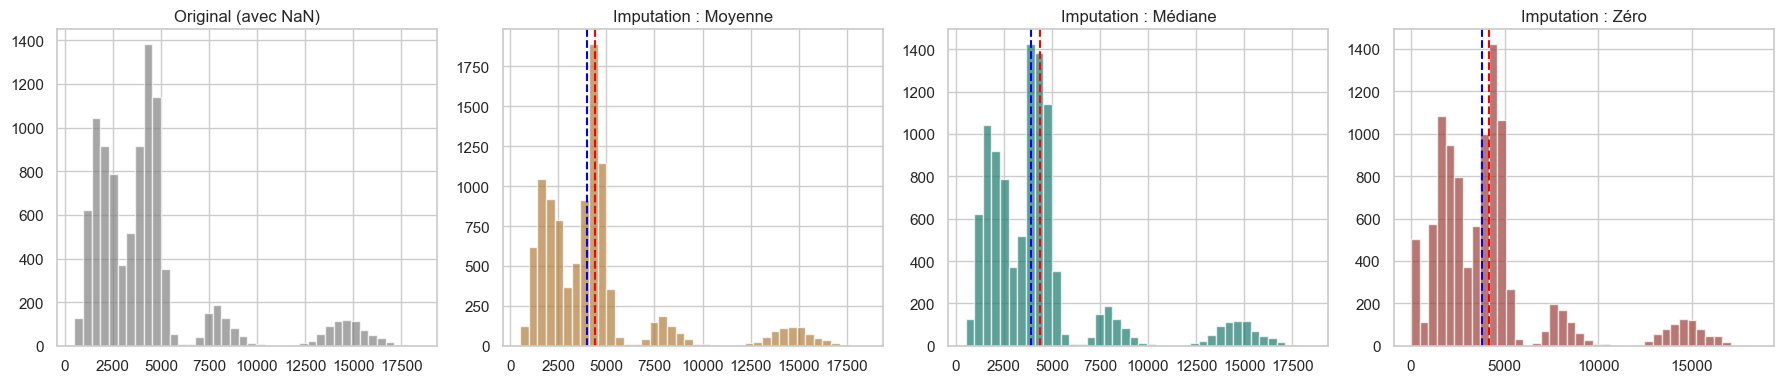

Stratégie          Moyenne     Médiane         Std
Moyenne             4410.0      4016.0      3320.3
Médiane             4384.4      3899.0      3322.2
Zéro                4189.6      3768.0      3456.5


In [5]:
# 5) Imputation comparison — Total_Trans_Amt
col = 'Total_Trans_Amt'
strategies = {
    'Moyenne':  SimpleImputer(strategy='mean'),
    'Médiane':  SimpleImputer(strategy='median'),
    'Zéro':     SimpleImputer(strategy='constant', fill_value=0),
}

data_imputed = {}
for name, imp in strategies.items():
    df_imp = datam.copy()
    df_imp[col] = imp.fit_transform(df_imp[[col]])
    data_imputed[name] = df_imp

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
axes[0].hist(datam[col].dropna(), bins=40, color='gray', alpha=.7)
axes[0].set_title('Original (avec NaN)')

colors = ['#B07D3A','#1A7A6E','#9C3D38']
for ax, (name, df_imp), c in zip(axes[1:], data_imputed.items(), colors):
    ax.hist(df_imp[col], bins=40, color=c, alpha=.7)
    ax.axvline(df_imp[col].mean(),   color='red',  ls='--', lw=1.5)
    ax.axvline(df_imp[col].median(), color='blue', ls='--', lw=1.5)
    ax.set_title(f'Imputation : {name}')
plt.tight_layout(); plt.show()

print(f"{'Stratégie':15s} {'Moyenne':>10s}  {'Médiane':>10s}  {'Std':>10s}")
for name, df_imp in data_imputed.items():
    s = df_imp[col]
    print(f"{name:15s} {s.mean():>10.1f}  {s.median():>10.1f}  {s.std():>10.1f}")

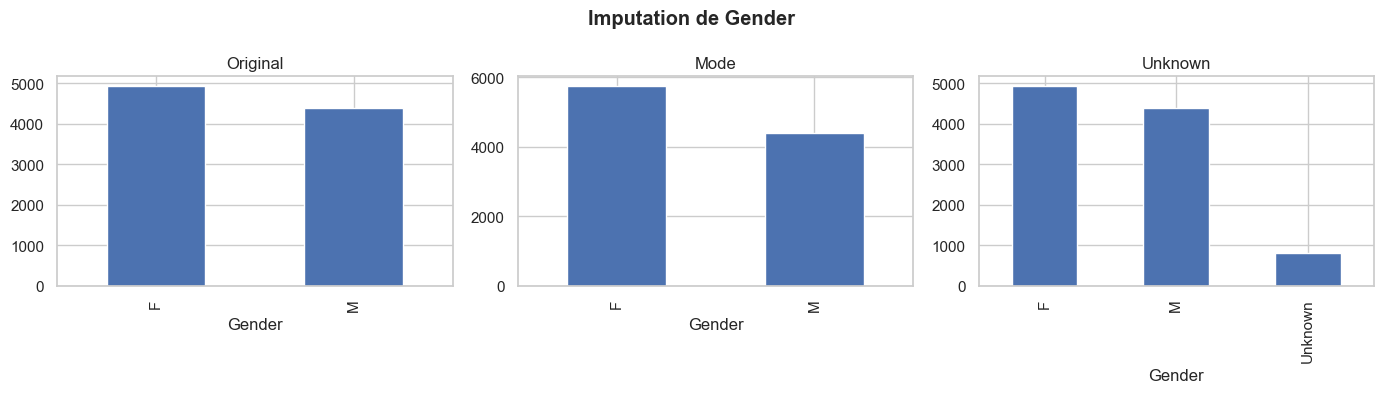

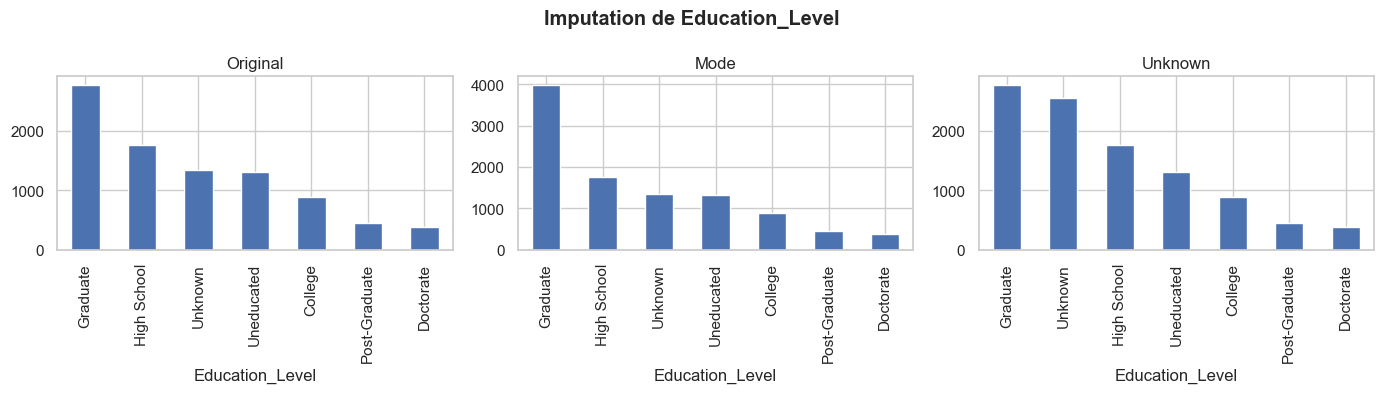

In [6]:
# 6) Categorical imputation — Gender and Education_Level
for col in ['Gender', 'Education_Level']:
    df_mode = datam.copy()
    imp_mode = SimpleImputer(strategy='most_frequent')
    df_mode[col] = imp_mode.fit_transform(df_mode[[col]]).ravel()

    df_unk = datam.copy()
    imp_unk = SimpleImputer(strategy='constant', fill_value='Unknown')
    df_unk[col] = imp_unk.fit_transform(df_unk[[col]]).ravel()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    datam[col].value_counts().plot(kind='bar', ax=axes[0], title='Original')
    df_mode[col].value_counts().plot(kind='bar', ax=axes[1], title='Mode')
    df_unk[col].value_counts().plot(kind='bar', ax=axes[2], title='Unknown')
    plt.suptitle(f'Imputation de {col}', fontweight='bold')
    plt.tight_layout(); plt.show()

In [7]:
# 7) Encodings
# Start from original data copy
if 'data' in globals():
    df_enc = data.copy()
    # Target
    df_enc['Attrition_Flag'] = df_enc['Attrition_Flag'].map({
        'Existing Customer': 0,
        'Attrited Customer': 1
    })
    # Binary
    df_enc['Gender'] = df_enc['Gender'].map({'M': 1, 'F': 0})
    df_enc['Marital_Status'] = df_enc['Marital_Status'].map({
        'Single': 0, 'Married': 1, 'Divorced': 2, 'Unknown': -1
    })
    # Ordinal
    education_order = ['Unknown', 'Uneducated', 'High School',
                       'College', 'Graduate', 'Post-Graduate', 'Doctorate']
    income_order = ['Unknown', 'Less than $40K', '$40K - $60K',
                    '$60K - $80K', '$80K - $120K', '$120K +']
    edu_map = {v: i for i, v in enumerate(education_order)}
    income_map = {v: i for i, v in enumerate(income_order)}
    df_enc['Education_Level'] = df_enc['Education_Level'].map(edu_map)
    df_enc['Income_Category'] = df_enc['Income_Category'].map(income_map)
    # One-Hot
    ohe = pd.get_dummies(df_enc['Card_Category'], prefix='card', drop_first=True, dtype=int)
    df_enc = pd.concat([df_enc.drop('Card_Category', axis=1), ohe], axis=1)
    # Check NaNs introduced
    check = ['Attrition_Flag', 'Gender', 'Marital_Status']
    print('NaN introduits :', df_enc[check].isna().sum().sum())
    display(df_enc.head())
else:
    print('Dataframe `data` not loaded.')

NaN introduits : 0


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Months_on_book,Total_Relationship_Count,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,card_Gold,card_Platinum,card_Silver
0,768805383,0,45,1,3,2,1,3,39,5,...,3,12691.0,777,11914.0,1.335,1144,42,0,0,0
1,818770008,0,49,0,5,4,0,1,44,6,...,2,8256.0,864,7392.0,1.541,1291,33,0,0,0
2,713982108,0,51,1,3,4,1,4,36,4,...,0,3418.0,0,3418.0,2.594,1887,20,0,0,0
3,769911858,0,40,0,4,2,-1,1,34,3,...,1,3313.0,2517,796.0,1.405,1171,20,0,0,0
4,709106358,0,40,1,3,1,1,3,21,5,...,0,4716.0,0,4716.0,2.175,816,28,0,0,0


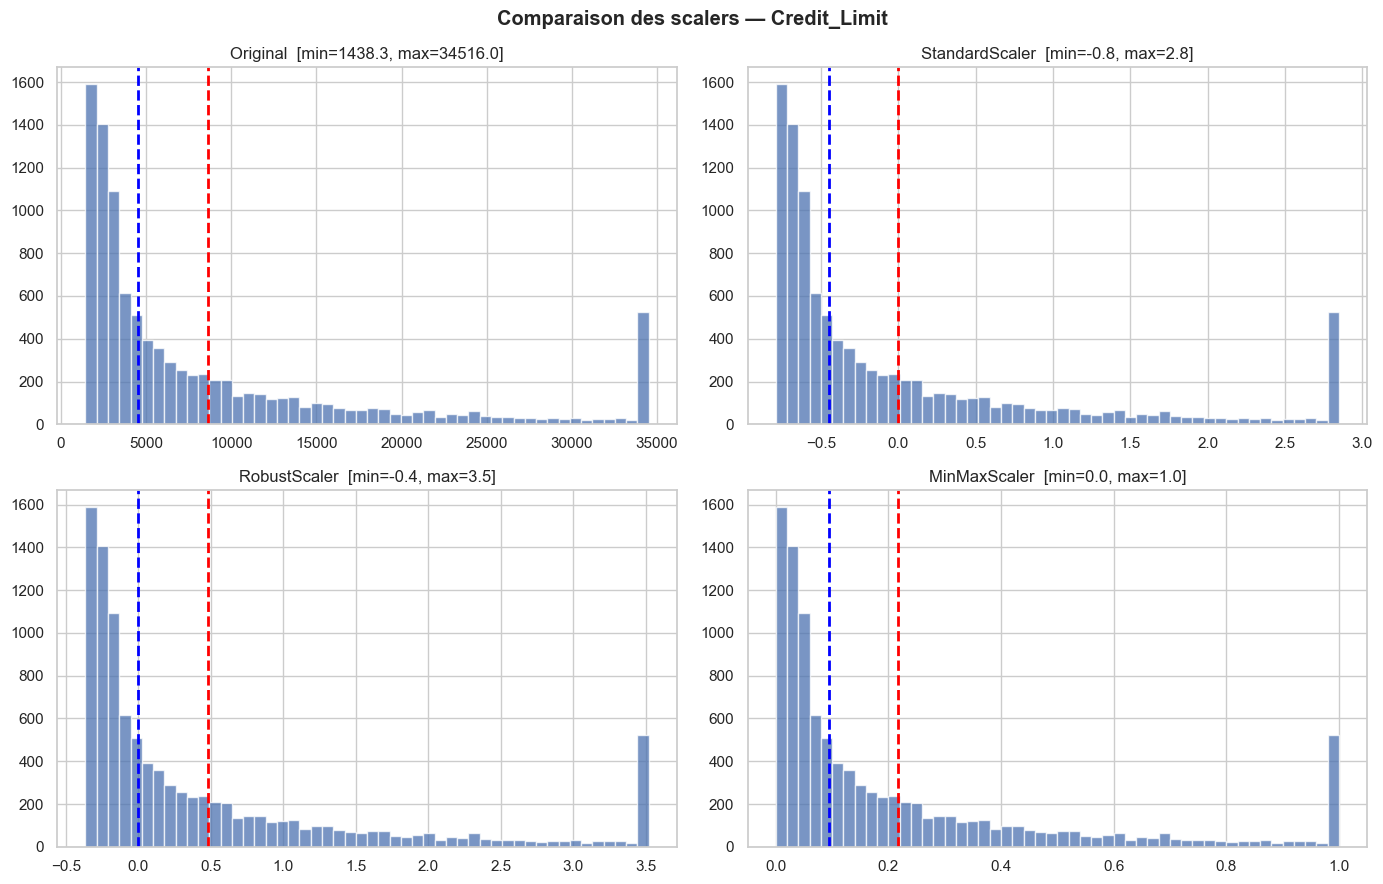

In [8]:
# 8) Scaler comparison — Credit_Limit
col = 'Credit_Limit'
X_col = data[[col]].values
scalers = {
    'Original':       data[col].values,
    'StandardScaler': StandardScaler().fit_transform(X_col).ravel(),
    'RobustScaler':   RobustScaler().fit_transform(X_col).ravel(),
    'MinMaxScaler':   MinMaxScaler().fit_transform(X_col).ravel(),
}
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for ax, (name, vals) in zip(axes, scalers.items()):
    ax.hist(vals, bins=50, alpha=.75, edgecolor='white')
    ax.axvline(vals.mean(), color='red', ls='--', lw=2)
    ax.axvline(np.median(vals), color='blue', ls='--', lw=2)
    ax.set_title(f'{name}  [min={vals.min():.1f}, max={vals.max():.1f}]')
plt.suptitle('Comparaison des scalers — Credit_Limit', fontweight='bold')
plt.tight_layout(); plt.show()

In [9]:
# 9) ColumnTransformer pipeline (robust to missing columns)
num_cols = ['Customer_Age','Credit_Limit','Total_Trans_Amt',
            'Total_Revolving_Bal','Avg_Utilization_Ratio',
            'Months_on_book','Total_Trans_Ct']
ord_cols = ['Education_Level', 'Income_Category']
nom_cols = ['Card_Category']
bin_cols = ['Gender', 'Marital_Status']

# Prepare X and y
if 'data' in globals():
    y = data['Attrition_Flag'].map({'Existing Customer':0,'Attrited Customer':1})
    X = data.drop('Attrition_Flag', axis=1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Filter lists to existing columns to avoid errors
    num_cols_exist = [c for c in num_cols if c in X_train.columns]
    ord_cols_exist = [c for c in ord_cols if c in X_train.columns]
    nom_cols_exist = [c for c in nom_cols if c in X_train.columns]
    bin_cols_exist = [c for c in bin_cols if c in X_train.columns]
    if not (len(num_cols_exist)==len(num_cols) and len(ord_cols_exist)==len(ord_cols) and len(nom_cols_exist)==len(nom_cols) and len(bin_cols_exist)==len(bin_cols)):
        print('Warning: some expected columns are missing and will be skipped:')
        missing = {
            'num': list(set(num_cols)-set(num_cols_exist)),
        'ord': list(set(ord_cols)-set(ord_cols_exist)),
        'nom': list(set(nom_cols)-set(nom_cols_exist)),
        'bin': list(set(bin_cols)-set(bin_cols_exist)),
        }
        print(missing)

    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', RobustScaler()),])
    ord_pipe = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
                         ('encoder', OrdinalEncoder(categories=[
                             ['Unknown','Uneducated','High School','College','Graduate','Post-Graduate','Doctorate'],
                             ['Unknown','Less than $40K','$40K - $60K','$60K - $80K','$80K - $120K','$120K +']
                         ], handle_unknown='use_encoded_value', unknown_value=-1)),])
    nom_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')),])
    bin_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('encoder', OrdinalEncoder()),])

    # Build transformers list dynamically based on available columns
    transformers = []
    if num_cols_exist:
        transformers.append(('num', num_pipe, num_cols_exist))
    if ord_cols_exist:
        transformers.append(('ord', ord_pipe, ord_cols_exist))
    if nom_cols_exist:
        transformers.append(('nom', nom_pipe, nom_cols_exist))
    if bin_cols_exist:
        transformers.append(('bin', bin_pipe, bin_cols_exist))

    if not transformers:
        raise RuntimeError('No columns available to build the preprocessor.')

    preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

    X_train_pp = preprocessor.fit_transform(X_train)
    X_test_pp = preprocessor.transform(X_test)
    print(f'X_train préprocessé : {X_train_pp.shape}')
    print(f'X_test  préprocessé : {X_test_pp.shape}')
    print(f'NaN restants : {np.isnan(X_train_pp).sum()}')

    # Save pipeline and splits
    joblib.dump(preprocessor, 'churn_preprocessor.pkl')
    joblib.dump((X_train_pp, X_test_pp, y_train, y_test), 'churn_splits.pkl')
    print('Saved churn_preprocessor.pkl and churn_splits.pkl')
else:
    print('Dataframe `data` not loaded.')

{'num': ['Avg_Utilization_Ratio'], 'ord': [], 'nom': [], 'bin': []}
X_train préprocessé : (8101, 13)
X_test  préprocessé : (2026, 13)
NaN restants : 0
Saved churn_preprocessor.pkl and churn_splits.pkl


In [10]:
# 10) Bonus — Feature engineering (robust to missing columns)
if 'data' in globals():
    df_feat = data.copy()
    # Trans_Per_Month: requires Total_Trans_Ct and Months_on_book
    if 'Total_Trans_Ct' in df_feat.columns and 'Months_on_book' in df_feat.columns:
        df_feat['Trans_Per_Month'] = (df_feat['Total_Trans_Ct'] / df_feat['Months_on_book']).replace([np.inf, -np.inf], np.nan)
    else:
        print('Warning: cannot compute Trans_Per_Month (missing Total_Trans_Ct or Months_on_book)')
        df_feat['Trans_Per_Month'] = np.nan
    # Is_Dormant: requires Avg_Utilization_Ratio and Total_Revolving_Bal
    if 'Avg_Utilization_Ratio' in df_feat.columns and 'Total_Revolving_Bal' in df_feat.columns:
        df_feat['Is_Dormant'] = ((df_feat['Avg_Utilization_Ratio'] == 0) & (df_feat['Total_Revolving_Bal'] == 0)).astype(int)
    else:
        missing = [c for c in ['Avg_Utilization_Ratio','Total_Revolving_Bal'] if c not in df_feat.columns]
        print(f'Warning: cannot compute Is_Dormant — missing columns: {missing}')
        df_feat['Is_Dormant'] = np.nan
    # Correlation with target if available
    if 'Attrition_Flag' in df_feat.columns:
        y_bin = df_feat['Attrition_Flag'].map({'Existing Customer':0,'Attrited Customer':1})
        for feat in ['Trans_Per_Month', 'Is_Dormant']:
            if feat in df_feat.columns and df_feat[feat].notna().any():
                try:
                    corr = df_feat[feat].corr(y_bin)
                    print(f'{feat:25s} → corr = {corr:.3f}')
                except Exception as e:
                    print(f'Could not compute corr for {feat}:', e)
            else:
                print(f'{feat:25s} → not available for correlation')
    else:
        print('Attrition_Flag not available; cannot compute correlations')
else:
    print('Dataframe `data` not loaded.')

Trans_Per_Month           → corr = -0.287
Is_Dormant                → not available for correlation


# Final synthesis

Résumé (~200 mots) :

Ce notebook suit une démarche de preprocessing reproductible pour le dataset BankChurners. Nous avons d'abord réalisé un diagnostic des types, des manquants simulés (MCAR) et des outliers afin de choisir des traitements adaptés. Les variables financières (Credit_Limit, Total_Trans_Amt) présentent des distributions asymétriques avec outliers ; nous recommandons l'utilisation de `RobustScaler` qui résiste aux valeurs extrêmes. Pour l'imputation numérique, la médiane est privilégiée lorsque la variable est asymétrique afin de préserver la robustesse; l'imputation par zéro crée des pics artificiels et doit être évitée sauf si 0 a un sens métier. Pour les variables catégorielles, le mode convient pour `Gender` (binaire) tandis que `Education_Level` contenant déjà des 'Unknown' justifie une imputation par constante cohérente avec l'information existante. Les variables ordinales (`Education_Level`, `Income_Category`) sont encodées ordinalement selon un ordre logique; les variables nominales (`Card_Category`) sont encodées en One-Hot avec `drop_first=True` pour éviter le dummy trap. Enfin, nous assemblons ces transformations dans un `ColumnTransformer` fitté uniquement sur le jeu d'entraînement et sauvegardé (`churn_preprocessor.pkl`) pour éviter toute fuite d'information et garantir reproductibilité.

(Complétez ce résumé avec vos commentaires et visualisations lorsque vous exécutez le notebook.)